# Condition Prevalence Analysis

Which conditions are most prevalent in the patient population, and what proportion of patients are affected by each condition?

In [2]:
import pandas as pd

In [3]:
conditions= pd.read_csv("C:\projects\Healthcare-Analytics-Dashboard\python\data\conditions.csv")

In [4]:
conditions.head(5)

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2019-02-15,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,d5ee30a9-362f-429e-a87a-ee38d999b0a5,65363002,Otitis media
1,2019-10-30,2020-01-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,8bca6d8a-ab80-4cbf-8abb-46654235f227,65363002,Otitis media
2,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,386661006,Fever (finding)
3,2020-03-01,2020-03-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840544004,Suspected COVID-19
4,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840539006,COVID-19


In [5]:
conditions.info()

<class 'pandas.DataFrame'>
RangeIndex: 114544 entries, 0 to 114543
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   START        114544 non-null  str  
 1   STOP         63096 non-null   str  
 2   PATIENT      114544 non-null  str  
 3   ENCOUNTER    114544 non-null  str  
 4   CODE         114544 non-null  int64
 5   DESCRIPTION  114544 non-null  str  
dtypes: int64(1), str(5)
memory usage: 17.1 MB


In [6]:
total_patients = conditions['PATIENT'].nunique()

print("Total unique patients:", total_patients)
print("Total condition records:", len(conditions))
print("Unique conditions:", conditions['DESCRIPTION'].nunique())

Total unique patients: 12165
Total condition records: 114544
Unique conditions: 180


# Calculate Condition Prevalence

calculate how many unique patients have each condition.

In [7]:
condition_prevalence = (
    conditions.groupby('DESCRIPTION')['PATIENT']
    .nunique()
    .reset_index(name='Unique Patients')
)

condition_prevalence['Prevalence (%)'] = (
    condition_prevalence['Unique Patients']
    / total_patients
    * 100
)

condition_prevalence = condition_prevalence.sort_values(
    'Unique Patients',
    ascending=False
)

condition_prevalence

,DESCRIPTION,Unique Patients,Prevalence (%)
170,Suspected COVID-19,9106,74.854090
28,COVID-19,8820,72.503083
67,Fever (finding),8083,66.444718
50,Cough (finding),6202,50.982326
23,Body mass index 30+ - obesity (finding),5002,41.117961
...,...,...,...
82,History of disarticulation at wrist (situation),1,0.008220
54,Diabetes from Cystic Fibrosis,1,0.008220
105,Lupus erythematosus,1,0.008220
139,Posttraumatic stress disorder,1,0.008220


Prepare the Top 10 for visualization

In [8]:
top_10_conditions = condition_prevalence.head(10).copy()

top_10_conditions['Prevalence (%)'] = (
    top_10_conditions['Prevalence (%)'].round(2)
)

top_10_conditions

,DESCRIPTION,Unique Patients,Prevalence (%)
170,Suspected COVID-19,9106,74.85
28,COVID-19,8820,72.50
67,Fever (finding),8083,66.44
50,Cough (finding),6202,50.98
23,Body mass index 30+ - obesity (finding),5002,41.12
104,Loss of taste (finding),4711,38.73
140,Prediabetes,3917,32.20
12,Anemia (disorder),3650,30.00
64,Fatigue (finding),3516,28.90
88,Hypertension,3168,26.04


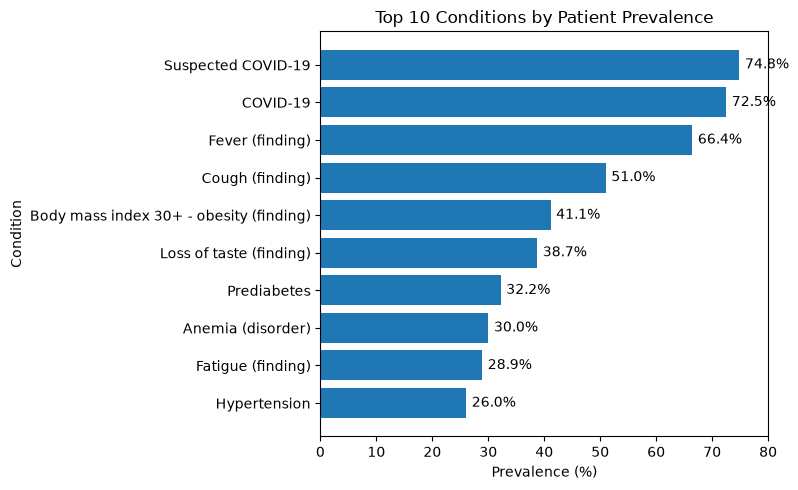

In [9]:
import matplotlib.pyplot as plt

plot_data = top_10_conditions.sort_values(
    'Prevalence (%)',
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data['DESCRIPTION'],
    plot_data['Prevalence (%)']
)

plt.xlabel('Prevalence (%)')
plt.ylabel('Condition')
plt.title('Top 10 Conditions by Patient Prevalence')

plt.xlim(0, 80)

for i, value in enumerate(plot_data['Prevalence (%)']):
    plt.text(
        value + 1,
        i,
        f'{value:.1f}%',
        va='center'
    )

plt.tight_layout()
plt.show()

Suspected COVID-19 was the most prevalent condition/finding, affecting 74.85% of patients in the condition dataset.
COVID-19 followed closely at 72.50%.
Fever was present in 66.44% and cough in 50.98%.
Among longer-term/metabolic conditions, obesity was particularly prevalent at 41.12%, followed by prediabetes (32.20%) and hypertension (26.04%).
Anemia affected 30.00% of patients.
The prevalence distribution shows a substantial gap between the most common COVID-related findings and the lower-ranked chronic conditions.

----Condition Burden by Age Group(How does the prevalence of major conditions vary across different age groups?)

In [10]:
patients=pd.read_csv("C:\projects\Healthcare-Analytics-Dashboard\python\data\patients.csv")

In [11]:
patients[['Id', 'BIRTHDATE']].head()

,Id,BIRTHDATE
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24
1,067318a4-db8f-447f-8b6e-f2f61e9baaa5,2016-08-01
2,ae9efba3-ddc4-43f9-a781-f72019388548,1992-06-30
3,199c586f-af16-4091-9998-ee4cfc02ee7a,2004-01-09
4,353016ea-a0ff-4154-85bb-1cf8b6cedf20,1996-11-15


In [12]:
patients.columns.tolist()

['Id',
 'BIRTHDATE',
 'DEATHDATE',
 'SSN',
 'DRIVERS',
 'PASSPORT',
 'PREFIX',
 'FIRST',
 'LAST',
 'SUFFIX',
 'MAIDEN',
 'MARITAL',
 'RACE',
 'ETHNICITY',
 'GENDER',
 'BIRTHPLACE',
 'ADDRESS',
 'CITY',
 'STATE',
 'COUNTY',
 'ZIP',
 'LAT',
 'LON',
 'HEALTHCARE_EXPENSES',
 'HEALTHCARE_COVERAGE']

In [13]:
print(conditions[['PATIENT', 'START', 'DESCRIPTION']].head())
print(conditions['START'].dtype)
print(patients['BIRTHDATE'].dtype)

                                PATIENT       START         DESCRIPTION
0  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271  2019-02-15        Otitis media
1  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271  2019-10-30        Otitis media
2  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271  2020-03-01     Fever (finding)
3  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271  2020-03-01  Suspected COVID-19
4  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271  2020-03-01            COVID-19
str
str


In [14]:
conditions['START'] = pd.to_datetime(conditions['START'])
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])

In [15]:
print(conditions['START'].dtype)
print(patients['BIRTHDATE'].dtype)

datetime64[us]
datetime64[us]


Merge patient demographics with conditions

In [16]:
condition_age = conditions.merge(
    patients[['Id', 'BIRTHDATE']],
    left_on='PATIENT',
    right_on='Id',
    how='left'
)

condition_age.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,Id,BIRTHDATE
0,2019-02-15,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,d5ee30a9-362f-429e-a87a-ee38d999b0a5,65363002,Otitis media,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24
1,2019-10-30,2020-01-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,8bca6d8a-ab80-4cbf-8abb-46654235f227,65363002,Otitis media,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24
2,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,386661006,Fever (finding),f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24
3,2020-03-01,2020-03-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840544004,Suspected COVID-19,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24
4,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840539006,COVID-19,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24


In [17]:
print("Total condition records:", len(condition_age))
print("Missing birth dates:", condition_age['BIRTHDATE'].isna().sum())

Total condition records: 114544
Missing birth dates: 0


Calculate Age at Condition Start

In [18]:
condition_age['AGE'] = (
    (condition_age['START'] - condition_age['BIRTHDATE']).dt.days
    / 365.25
).astype(int)

In [19]:
condition_age[['BIRTHDATE', 'START', 'DESCRIPTION', 'AGE']].head(10)

,BIRTHDATE,START,DESCRIPTION,AGE
0,2017-08-24,2019-02-15,Otitis media,1
1,2017-08-24,2019-10-30,Otitis media,2
2,2017-08-24,2020-03-01,Fever (finding),2
3,2017-08-24,2020-03-01,Suspected COVID-19,2
4,2017-08-24,2020-03-01,COVID-19,2
5,2016-08-01,2020-02-12,Sprain of ankle,3
6,2016-08-01,2020-03-13,Cough (finding),3
7,2016-08-01,2020-03-13,Sputum finding (finding),3
8,2016-08-01,2020-03-13,Diarrhea symptom (finding),3
9,2016-08-01,2020-03-13,Fever (finding),3


In [20]:
print("Minimum age:", condition_age['AGE'].min())
print("Maximum age:", condition_age['AGE'].max())
print("Missing ages:", condition_age['AGE'].isna().sum())

Minimum age: 0
Maximum age: 110
Missing ages: 0


In [21]:
print("Negative ages:", (condition_age['AGE'] < 0).sum())
print("Age > 100:", (condition_age['AGE'] > 100).sum())

Negative ages: 0
Age > 100: 867


In [22]:
condition_age[condition_age['AGE'] < 0][
    ['BIRTHDATE', 'START', 'DESCRIPTION', 'AGE']
].head()

,BIRTHDATE,START,DESCRIPTION,AGE


Create Age Groups

In [23]:
condition_age['AGE_GROUP'] = pd.cut(
    condition_age['AGE'],
    bins=[-1, 17, 39, 59, 79, float('inf')],
    labels=[
        'Pediatric',
        'Young Adult',
        'Middle-aged',
        'Older Adult',
        'Elderly'
    ]
)

In [24]:
condition_age['AGE_GROUP'].value_counts().sort_index()

AGE_GROUP
Pediatric      18725
Young Adult    39050
Middle-aged    31895
Older Adult    19062
Elderly         5812
Name: count, dtype: int64

Establish the age-group patient denominators

In [25]:
age_group_patients = (
    condition_age.groupby('AGE_GROUP', observed=True)['PATIENT']
    .nunique()
    .reset_index(name='Unique Patients')
)

age_group_patients

,AGE_GROUP,Unique Patients
0,Pediatric,5259
1,Young Adult,8864
2,Middle-aged,6034
3,Older Adult,3305
4,Elderly,916


In [26]:
print("Total unique patients:", condition_age['PATIENT'].nunique())  #this unique patients total is used as denominator always

Total unique patients: 12165


For the overall Condition Prevalence Analysis, yes — we used 12,165 as the denominator.

But for age-group-specific prevalence, we should not automatically use 12,165.

Why? Because the age groups represent age at condition onset, and the same patient can appear in multiple age groups over their lifetime.

For example:

Patient A
   ↓
Age 15 → Otitis media → Pediatric
   ↓
Age 45 → Hypertension → Middle-aged
   ↓
Age 72 → Diabetes → Older Adult

For the age-group analysis, the appropriate denominator is therefore the unique patients represented within that age group.

--->Calculate condition prevalence within each age group(How many patients had each condition within each age group?)

Condition prevalence within age group=Unique patients represented in that age group / Unique patients with condition in that age group  ​ ×100

In [27]:
age_condition_prevalence = (
    condition_age
    .groupby(['AGE_GROUP', 'DESCRIPTION'], observed=True)['PATIENT']
    .nunique()
    .reset_index(name='Unique Patients')
)

age_condition_prevalence = age_condition_prevalence.merge(
    age_group_patients,
    on='AGE_GROUP',
    how='left'
)

age_condition_prevalence['Prevalence (%)'] = (
    age_condition_prevalence['Unique Patients_x']                 #Patients with THIS condition
    / age_condition_prevalence['Unique Patients_y']               #Total patients represented in THIS age group
    * 100
)

age_condition_prevalence = age_condition_prevalence.rename(
    columns={
        'Unique Patients_x': 'Patients with Condition',
        'Unique Patients_y': 'Patients in Age Group'
    }
)

age_condition_prevalence

,AGE_GROUP,DESCRIPTION,Patients with Condition,Patients in Age Group,Prevalence (%)
0,Pediatric,Acute allergic reaction,15,5259,0.285225
1,Pediatric,Acute bacterial sinusitis (disorder),17,5259,0.323255
2,Pediatric,Acute bronchitis (disorder),148,5259,2.814223
3,Pediatric,Acute deep venous thrombosis (disorder),29,5259,0.551436
4,Pediatric,Acute pulmonary embolism (disorder),43,5259,0.817646
...,...,...,...,...,...
642,Elderly,Suspected lung cancer (situation),9,916,0.982533
643,Elderly,Viral sinusitis (disorder),93,916,10.152838
644,Elderly,Vomiting symptom (finding),29,916,3.165939
645,Elderly,Wheezing (finding),98,916,10.698690


In [28]:
"""CONDITION DATA
     ↓
Group by AGE_GROUP + CONDITION
     ↓
Count UNIQUE PATIENTS
     ↓
Patients with Condition
     ↓
MERGE with
     ↓
Unique Patients in Age Group
     ↓
Patients with Condition
──────────────────────── × 100
Patients in Age Group
     ↓
CONDITION PREVALENCE (%)"""

'CONDITION DATA\n     ↓\nGroup by AGE_GROUP + CONDITION\n     ↓\nCount UNIQUE PATIENTS\n     ↓\nPatients with Condition\n     ↓\nMERGE with\n     ↓\nUnique Patients in Age Group\n     ↓\nPatients with Condition\n──────────────────────── × 100\nPatients in Age Group\n     ↓\nCONDITION PREVALENCE (%)'

# Condition Duration / Persistence Analysis

Which conditions have the longest and shortest documented durations among patients?

In [29]:
print("Total condition records:", len(conditions))
print("Conditions with STOP date:", conditions['STOP'].notna().sum())
print("Conditions without STOP date:", conditions['STOP'].isna().sum())  #null values

print(
    "Percentage without STOP:",
    round(conditions['STOP'].isna().mean() * 100, 2),
    "%"
)

Total condition records: 114544
Conditions with STOP date: 63096
Conditions without STOP date: 51448
Percentage without STOP: 44.92 %


In [30]:
conditions[['START', 'STOP', 'DESCRIPTION']].head(10)

,START,STOP,DESCRIPTION
0,2019-02-15,2019-08-01,Otitis media
1,2019-10-30,2020-01-30,Otitis media
2,2020-03-01,2020-03-30,Fever (finding)
3,2020-03-01,2020-03-01,Suspected COVID-19
4,2020-03-01,2020-03-30,COVID-19
5,2020-02-12,2020-02-26,Sprain of ankle
6,2020-03-13,2020-04-14,Cough (finding)
7,2020-03-13,2020-04-14,Sputum finding (finding)
8,2020-03-13,2020-04-14,Diarrhea symptom (finding)
9,2020-03-13,2020-04-14,Fever (finding)


In [31]:
#So we should calculate duration only for the 63,096 resolved/documented condition records. We should not substitute today's date for missing STOP dates because that would artificially inflate durations.

In [32]:
conditions['START']=pd.to_datetime(conditions['START'])
conditions['STOP']=pd.to_datetime(conditions['STOP'])

In [33]:
print(conditions['START'].dtypes)
print(conditions['STOP'].dtypes)

datetime64[us]
datetime64[us]


In [34]:
resolved_conditions = conditions[
    conditions['STOP'].notna()
].copy()

In [35]:
print("Resolved condition records:", len(resolved_conditions))
print("Missing STOP dates:", resolved_conditions['STOP'].isna().sum())

Resolved condition records: 63096
Missing STOP dates: 0


Calculate condition duration

In [36]:
resolved_conditions['DURATION_DAYS'] = (resolved_conditions['STOP']-resolved_conditions['START']).dt.days

In [37]:
resolved_conditions[
    ['START', 'STOP', 'DESCRIPTION', 'DURATION_DAYS']
].head(10)

,START,STOP,DESCRIPTION,DURATION_DAYS
0,2019-02-15,2019-08-01,Otitis media,167
1,2019-10-30,2020-01-30,Otitis media,92
2,2020-03-01,2020-03-30,Fever (finding),29
3,2020-03-01,2020-03-01,Suspected COVID-19,0
4,2020-03-01,2020-03-30,COVID-19,29
5,2020-02-12,2020-02-26,Sprain of ankle,14
6,2020-03-13,2020-04-14,Cough (finding),32
7,2020-03-13,2020-04-14,Sputum finding (finding),32
8,2020-03-13,2020-04-14,Diarrhea symptom (finding),32
9,2020-03-13,2020-04-14,Fever (finding),32


In [38]:
print("Minimum duration:", resolved_conditions['DURATION_DAYS'].min())
print("Maximum duration:", resolved_conditions['DURATION_DAYS'].max())
print("Negative durations:", (resolved_conditions['DURATION_DAYS'] < 0).sum())
print("Zero-day conditions:", (resolved_conditions['DURATION_DAYS'] == 0).sum())

Minimum duration: 0
Maximum duration: 9758
Negative durations: 0
Zero-day conditions: 8919


Among resolved records, what is the typical duration of each condition?

calculate:

Number of resolved records,
Mean duration,
Median duration,
Minimum duration,
Maximum duration.

In [39]:
condition_duration = (
    resolved_conditions
    .groupby('DESCRIPTION')['DURATION_DAYS']
    .agg(
        Resolved_Records='count',
        Mean_Duration_Days='mean',
        Median_Duration_Days='median',
        Min_Duration_Days='min',
        Max_Duration_Days='max'
    )
    .reset_index()
)

In [40]:
condition_duration[
    [
        'Mean_Duration_Days',
        'Median_Duration_Days'
    ]
] = condition_duration[
    [
        'Mean_Duration_Days',
        'Median_Duration_Days'
    ]
].round(2)

In [41]:
condition_duration.head(10)

,DESCRIPTION,Resolved_Records,Mean_Duration_Days,Median_Duration_Days,Min_Duration_Days,Max_Duration_Days
0,Acquired coagulation disorder (disorder),11,5.45,6.0,2,8
1,Acute Cholecystitis,3,0.00,0.0,0,0
2,Acute allergic reaction,16,0.12,0.0,0,1
3,Acute bacterial sinusitis (disorder),75,70.56,42.0,7,273
4,Acute bronchitis (disorder),693,10.33,7.0,7,15
5,Acute deep venous thrombosis (disorder),443,3.17,3.0,0,14
6,Acute pulmonary embolism (disorder),432,3.01,3.0,0,14
7,Acute respiratory distress syndrome (disorder),8,6.38,7.5,3,9
8,Acute respiratory failure (disorder),520,11.23,11.0,8,21
9,Acute viral pharyngitis (disorder),791,10.02,10.0,7,13


some conditions have very few resolved records. For example, Acute Cholecystitis has only 3 records. Ranking such conditions could produce misleading "longest duration" results because a single unusual record can dominate the average.

In [42]:
condition_duration_reliable = condition_duration[condition_duration['Resolved_Records']>10].copy()

In [43]:
print("Total conditions:", len(condition_duration))
print("Conditions with at least 10 resolved records:",
      len(condition_duration_reliable))

Total conditions: 91
Conditions with at least 10 resolved records: 69


Our analytical question now becomes

Among conditions with at least 10 documented resolved episodes, which 10 have the longest typical duration?

In [44]:
top_10_longest = (
    condition_duration_reliable
    .sort_values(
        'Median_Duration_Days',
        ascending=False
    )
    .head(10)
)

top_10_longest

,DESCRIPTION,Resolved_Records,Mean_Duration_Days,Median_Duration_Days,Min_Duration_Days,Max_Duration_Days
86,Tubal pregnancy,19,2395.47,868.0,14,9758
16,Child attention deficit disorder,18,1100.22,679.0,28,4025
71,Recurrent rectal polyp,13,456.92,480.0,390,510
67,Polyp of colon,164,489.23,450.0,360,996
10,Anemia (disorder),33,185.18,217.0,0,231
59,Normal pregnancy,1082,143.11,210.0,7,238
60,Otitis media,209,122.77,102.0,14,680
77,Sinusitis (disorder),83,81.72,63.0,14,315
20,Chronic sinusitis (disorder),38,1242.68,63.0,7,8585
24,Concussion with no loss of consciousness,68,47.65,60.0,30,60


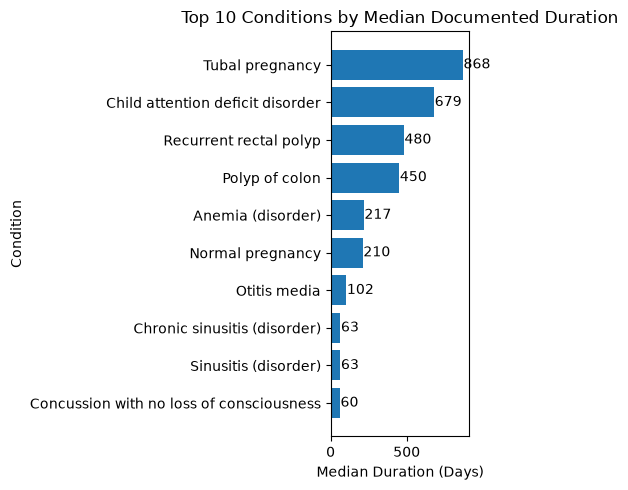

In [45]:
import matplotlib.pyplot as plt

plot_data = top_10_longest.sort_values(
    'Median_Duration_Days',
    ascending=True
)

plt.figure(figsize=(5, 5))

bars = plt.barh(
    plot_data['DESCRIPTION'],
    plot_data['Median_Duration_Days']
)

plt.xlabel('Median Duration (Days)')
plt.ylabel('Condition')
plt.title('Top 10 Conditions by Median Documented Duration')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}',
        va='center'
    )

plt.tight_layout()
plt.show()

# Condition Co-occurrence Analysis

Which pairs of conditions are most frequently documented in the same patients?

This is a comorbidity / co-occurrence analysis.

Prepare unique patient- unique condition combinations

In [46]:
patient_conditions = conditions[['DESCRIPTION','PATIENT']].drop_duplicates().copy()

In [47]:
patient_conditions = (
    conditions[['PATIENT', 'DESCRIPTION']]
    .drop_duplicates()
    .copy()
)

print("Original condition records:", len(conditions))
print("Unique patient-condition pairs:", len(patient_conditions))
print("Unique patients:", patient_conditions['PATIENT'].nunique())
print("Unique conditions:", patient_conditions['DESCRIPTION'].nunique())

Original condition records: 114544
Unique patient-condition pairs: 113239
Unique patients: 12165
Unique conditions: 180


Check how many different conditions patients have

In [48]:
patient_condition_count = (
    patient_conditions
    .groupby('PATIENT')['DESCRIPTION']
    .nunique()
)

patient_condition_count.describe()

count    12165.000000
mean         9.308590
std          4.865213
min          1.000000
25%          6.000000
50%          8.000000
75%         12.000000
max         40.000000
Name: DESCRIPTION, dtype: float64

In [49]:
print(
    "Patients with only 1 condition:",
    (patient_condition_count == 1).sum()
)

print(
    "Patients with 2 or more conditions:",
    (patient_condition_count >= 2).sum()
)

print(
    "Patients with 3 or more conditions:",
    (patient_condition_count >= 3).sum()
)

Patients with only 1 condition: 232
Patients with 2 or more conditions: 11933
Patients with 3 or more conditions: 11648


Create condition pairs within each patient(generate every unique pair of conditions belonging to the same patient USING itertools.combinations().)

In [50]:
from itertools import combinations

In [51]:
condition_pairs = []

for patient, group in patient_conditions.groupby('PATIENT'):
    conditions_list = sorted(group['DESCRIPTION'].unique())
    
    for condition_a, condition_b in combinations(conditions_list, 2):
        condition_pairs.append(
            (condition_a, condition_b)
        )

In [52]:
condition_pairs = pd.DataFrame(
    condition_pairs,
    columns=['Condition_A', 'Condition_B']
)

In [53]:
print("Total condition pairs:", len(condition_pairs))
condition_pairs.head(10)

Total condition pairs: 614391


,Condition_A,Condition_B
0,COVID-19,Cough (finding)
1,COVID-19,Fever (finding)
2,COVID-19,Headache (finding)
3,COVID-19,Sputum finding (finding)
4,COVID-19,Suspected COVID-19
5,Cough (finding),Fever (finding)
6,Cough (finding),Headache (finding)
7,Cough (finding),Sputum finding (finding)
8,Cough (finding),Suspected COVID-19
9,Fever (finding),Headache (finding)


count those repetitions to determine how many patients share each condition pair.

In [54]:
condition_pair_counts = (
    condition_pairs
    .value_counts()
    .reset_index(name='Patients')
)

In [55]:
condition_pair_counts.head(10)

,Condition_A,Condition_B,Patients
0,COVID-19,Suspected COVID-19,8820
1,Fever (finding),Suspected COVID-19,8083
2,COVID-19,Fever (finding),7840
3,Cough (finding),Suspected COVID-19,6202
4,COVID-19,Cough (finding),6020
5,Cough (finding),Fever (finding),5513
6,Loss of taste (finding),Suspected COVID-19,4711
7,COVID-19,Loss of taste (finding),4547
8,Fever (finding),Loss of taste (finding),4168
9,Fatigue (finding),Suspected COVID-19,3516


In [56]:
top_20_condition_pairs = condition_pair_counts.head(20)

top_20_condition_pairs

,Condition_A,Condition_B,Patients
0,COVID-19,Suspected COVID-19,8820
1,Fever (finding),Suspected COVID-19,8083
2,COVID-19,Fever (finding),7840
3,Cough (finding),Suspected COVID-19,6202
4,COVID-19,Cough (finding),6020
5,Cough (finding),Fever (finding),5513
6,Loss of taste (finding),Suspected COVID-19,4711
7,COVID-19,Loss of taste (finding),4547
8,Fever (finding),Loss of taste (finding),4168
9,Fatigue (finding),Suspected COVID-19,3516


strongest pairs are heavily dominated by COVID-related conditionS

Calculate pair prevalence

In [57]:
total_patients = patient_conditions['PATIENT'].nunique()

condition_pair_counts['Prevalence (%)'] = (
    condition_pair_counts['Patients']  # HERE THIS PATIENT MEANS PATIENTS HAVING BOTH CONDITIONS
    / total_patients
    * 100
)

condition_pair_counts['Prevalence (%)'] = (
    condition_pair_counts['Prevalence (%)'].round(2)
)

In [58]:
condition_pair_counts.head(20)

,Condition_A,Condition_B,Patients,Prevalence (%)
0,COVID-19,Suspected COVID-19,8820,72.50
1,Fever (finding),Suspected COVID-19,8083,66.44
2,COVID-19,Fever (finding),7840,64.45
3,Cough (finding),Suspected COVID-19,6202,50.98
4,COVID-19,Cough (finding),6020,49.49
5,Cough (finding),Fever (finding),5513,45.32
6,Loss of taste (finding),Suspected COVID-19,4711,38.73
7,COVID-19,Loss of taste (finding),4547,37.38
8,Fever (finding),Loss of taste (finding),4168,34.26
9,Fatigue (finding),Suspected COVID-19,3516,28.90


Examine non-COVID condition pairs

In [59]:
covid_conditions = [
    'COVID-19',
    'Suspected COVID-19'
]

non_covid_pairs = condition_pair_counts[
    ~condition_pair_counts['Condition_A'].isin(covid_conditions)
    &
    ~condition_pair_counts['Condition_B'].isin(covid_conditions)
].copy()

In [60]:
non_covid_pairs.head(20)

,Condition_A,Condition_B,Patients,Prevalence (%)
5,Cough (finding),Fever (finding),5513,45.32
8,Fever (finding),Loss of taste (finding),4168,34.26
13,Cough (finding),Loss of taste (finding),3190,26.22
14,Anemia (disorder),Prediabetes,3156,25.94
15,Fatigue (finding),Fever (finding),3114,25.60
16,Body mass index 30+ - obesity (finding),Fever (finding),3099,25.47
20,Fever (finding),Sputum finding (finding),2625,21.58
22,Fever (finding),Prediabetes,2404,19.76
23,Body mass index 30+ - obesity (finding),Cough (finding),2400,19.73
25,Cough (finding),Fatigue (finding),2396,19.70


In [61]:
top_10_non_covid_pairs = non_covid_pairs.head(10)

top_10_non_covid_pairs

,Condition_A,Condition_B,Patients,Prevalence (%)
5,Cough (finding),Fever (finding),5513,45.32
8,Fever (finding),Loss of taste (finding),4168,34.26
13,Cough (finding),Loss of taste (finding),3190,26.22
14,Anemia (disorder),Prediabetes,3156,25.94
15,Fatigue (finding),Fever (finding),3114,25.60
16,Body mass index 30+ - obesity (finding),Fever (finding),3099,25.47
20,Fever (finding),Sputum finding (finding),2625,21.58
22,Fever (finding),Prediabetes,2404,19.76
23,Body mass index 30+ - obesity (finding),Cough (finding),2400,19.73
25,Cough (finding),Fatigue (finding),2396,19.70


Condition prevalence by gender(Which conditions are more prevalent among male vs female patients)

In [62]:
condition_gender = conditions.merge(
    patients[['Id', 'GENDER']],
    left_on='PATIENT',
    right_on='Id',
    how='left'
)                            #Merge gender into the condition data

condition_gender.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,Id,GENDER
0,2019-02-15,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,d5ee30a9-362f-429e-a87a-ee38d999b0a5,65363002,Otitis media,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M
1,2019-10-30,2020-01-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,8bca6d8a-ab80-4cbf-8abb-46654235f227,65363002,Otitis media,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M
2,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,386661006,Fever (finding),f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M
3,2020-03-01,2020-03-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840544004,Suspected COVID-19,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M
4,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840539006,COVID-19,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M


Create unique patient-condition combination

In [63]:
patient_condition_gender = (
    condition_gender[['PATIENT', 'GENDER', 'DESCRIPTION']]
    .drop_duplicates()
)

patient_condition_gender.head()

,PATIENT,GENDER,DESCRIPTION
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M,Otitis media
2,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M,Fever (finding)
3,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M,Suspected COVID-19
4,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M,COVID-19
5,067318a4-db8f-447f-8b6e-f2f61e9baaa5,F,Sprain of ankle


Check gender completeness

In [64]:
print("Total condition records:", len(condition_gender))
print("Missing gender:", condition_gender['GENDER'].isna().sum())
print("Gender distribution:")
print(condition_gender['GENDER'].value_counts(dropna=False))

Total condition records: 114544
Missing gender: 0
Gender distribution:
GENDER
F    59403
M    55141
Name: count, dtype: int64


In [65]:
gender_patient_counts = (
    patient_condition_gender
    .groupby('GENDER')['PATIENT']
    .nunique()
    .reset_index(name='Patients in Gender')
)

gender_patient_counts

,GENDER,Patients in Gender
0,F,6162
1,M,6003


count unique patients for each condition within each gender

In [66]:
gender_condition_counts = (
    patient_condition_gender
    .groupby(['GENDER', 'DESCRIPTION'])['PATIENT']
    .nunique()
    .reset_index(name='Patients with Condition')
)

gender_condition_counts

,GENDER,DESCRIPTION,Patients with Condition
0,F,Acquired coagulation disorder (disorder),59
1,F,Acute Cholecystitis,2
2,F,Acute allergic reaction,7
3,F,Acute bacterial sinusitis (disorder),43
4,F,Acute bronchitis (disorder),333
...,...,...,...
335,M,Traumatic brain injury (disorder),7
336,M,Viral sinusitis (disorder),648
337,M,Vomiting symptom (finding),227
338,M,Wheezing (finding),855


Condition Prevalence by Gender

In [67]:
#gender_patient_counts → unique patients in each gender
#gender_condition_counts → unique patients of each gender with each condition

In [68]:
gender_condition_prevalence = gender_condition_counts.merge(
    gender_patient_counts,
    on='GENDER',
    how='left'
)

gender_condition_prevalence

,GENDER,DESCRIPTION,Patients with Condition,Patients in Gender
0,F,Acquired coagulation disorder (disorder),59,6162
1,F,Acute Cholecystitis,2,6162
2,F,Acute allergic reaction,7,6162
3,F,Acute bacterial sinusitis (disorder),43,6162
4,F,Acute bronchitis (disorder),333,6162
...,...,...,...,...
335,M,Traumatic brain injury (disorder),7,6003
336,M,Viral sinusitis (disorder),648,6003
337,M,Vomiting symptom (finding),227,6003
338,M,Wheezing (finding),855,6003


In [69]:
gender_condition_prevalence['Prevalence (%)'] = (
    gender_condition_prevalence['Patients with Condition']
    / gender_condition_prevalence['Patients in Gender']     #patients of that gender with the condition ÷ all patients of that gender
) * 100

In [70]:
gender_condition_prevalence

,GENDER,DESCRIPTION,Patients with Condition,Patients in Gender,Prevalence (%)
0,F,Acquired coagulation disorder (disorder),59,6162,0.957481
1,F,Acute Cholecystitis,2,6162,0.032457
2,F,Acute allergic reaction,7,6162,0.113599
3,F,Acute bacterial sinusitis (disorder),43,6162,0.697825
4,F,Acute bronchitis (disorder),333,6162,5.404090
...,...,...,...,...,...
335,M,Traumatic brain injury (disorder),7,6003,0.116608
336,M,Viral sinusitis (disorder),648,6003,10.794603
337,M,Vomiting symptom (finding),227,6003,3.781443
338,M,Wheezing (finding),855,6003,14.242879


In [71]:
gender_condition_prevalence['Prevalence (%)'] = (
    gender_condition_prevalence['Prevalence (%)'].round(2)
)

In [72]:
gender_condition_prevalence

,GENDER,DESCRIPTION,Patients with Condition,Patients in Gender,Prevalence (%)
0,F,Acquired coagulation disorder (disorder),59,6162,0.96
1,F,Acute Cholecystitis,2,6162,0.03
2,F,Acute allergic reaction,7,6162,0.11
3,F,Acute bacterial sinusitis (disorder),43,6162,0.70
4,F,Acute bronchitis (disorder),333,6162,5.40
...,...,...,...,...,...
335,M,Traumatic brain injury (disorder),7,6003,0.12
336,M,Viral sinusitis (disorder),648,6003,10.79
337,M,Vomiting symptom (finding),227,6003,3.78
338,M,Wheezing (finding),855,6003,14.24


# Condition Burden by Gender

Do males and females differ in the number of unique conditions they have?

How many different conditions does each patient have, and does that burden differ by gender?

Create unique patient-condition combinations

In [73]:
patient_condition_gender_unique = (
    patient_condition_gender[
        ['PATIENT', 'GENDER', 'DESCRIPTION']
    ]
    .drop_duplicates()   #Ensures that the same patient-condition combination is counted only once.
    .copy()
)

patient_condition_gender_unique.head()

,PATIENT,GENDER,DESCRIPTION
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M,Otitis media
2,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M,Fever (finding)
3,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M,Suspected COVID-19
4,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,M,COVID-19
5,067318a4-db8f-447f-8b6e-f2f61e9baaa5,F,Sprain of ankle


Count conditions for each patient

In [74]:
patient_condition_burden = (
    patient_condition_gender_unique
    .groupby(['PATIENT', 'GENDER'])['DESCRIPTION']
    .nunique()
    .reset_index(name='Condition Count')
)

patient_condition_burden

,PATIENT,GENDER,Condition Count
0,0000b247-1def-417a-a783-41c8682be022,F,6
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,M,11
2,000769a6-23a7-426e-a264-cb0e509b2da2,F,4
3,00079a57-24a8-430f-b4f8-a1cf34f90060,F,12
4,0008a63c-c95c-46c2-9ef3-831d68892019,M,16
...,...,...,...
12160,ffd3d544-1fcd-4a87-9514-fa6c37409cbc,M,5
12161,ffd86fda-ebb9-400e-9fe3-ea1a1037dbad,F,9
12162,ffdbbb1b-745e-4e38-ade2-a19d6e778fee,M,21
12163,ffdf0900-bc4b-4f81-b95b-1ea57da21e07,M,9


Compare condition burden between genders

In [75]:
gender_condition_burden = (
    patient_condition_burden
    .groupby('GENDER')['Condition Count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

gender_condition_burden

,GENDER,count,mean,median,min,max
0,F,6162,9.478578,9.0,1,36
1,M,6003,9.134100,8.0,1,40


In [76]:
patient_condition_burden['Condition Count'].describe()

count    12165.000000
mean         9.308590
std          4.865213
min          1.000000
25%          6.000000
50%          8.000000
75%         12.000000
max         40.000000
Name: Condition Count, dtype: float64

In [77]:
print(
    "Patients with 1 condition:",
    (patient_condition_burden['Condition Count'] == 1).sum()
)

print(
    "Patients with 2-4 conditions:",
    patient_condition_burden['Condition Count'].between(2, 4).sum()
)

print(
    "Patients with 5-9 conditions:",
    patient_condition_burden['Condition Count'].between(5, 9).sum()
)

print(
    "Patients with 10+ conditions:",
    (patient_condition_burden['Condition Count'] >= 10).sum()
)

Patients with 1 condition: 232
Patients with 2-4 conditions: 1342
Patients with 5-9 conditions: 5698
Patients with 10+ conditions: 4893


# Condition Trends Over Time.

How has the occurrence of conditions changed across calendar years?

Year → number of condition records

In [78]:
conditions['YEAR'] = conditions['START'].dt.year

conditions[['START', 'DESCRIPTION', 'YEAR']].head()

,START,DESCRIPTION,YEAR
0,2019-02-15,Otitis media,2019
1,2019-10-30,Otitis media,2019
2,2020-03-01,Fever (finding),2020
3,2020-03-01,Suspected COVID-19,2020
4,2020-03-01,COVID-19,2020


In [79]:
condition_year_counts = (
    conditions
    .groupby('YEAR')
    .size()
    .reset_index(name='Condition Records')
)

condition_year_counts

,YEAR,Condition Records
0,1910,2
1,1911,1
2,1912,8
3,1913,1
4,1914,2
...,...,...
106,2016,1027
107,2017,1014
108,2018,1182
109,2019,3736


Find the most common conditions by year

In [80]:
year_condition_counts = (
    conditions
    .groupby(['YEAR', 'DESCRIPTION'])
    .size()
    .reset_index(name='Patients/Records')
)

year_condition_counts

,YEAR,DESCRIPTION,Patients/Records
0,1910,History of single seizure (situation),1
1,1910,Seizure disorder,1
2,1911,Epilepsy,1
3,1912,Cardiac Arrest,2
4,1912,Chronic sinusitis (disorder),1
...,...,...,...
5618,2020,Tubal pregnancy,3
5619,2020,Viral sinusitis (disorder),431
5620,2020,Vomiting symptom (finding),496
5621,2020,Wheezing (finding),1816


Get the top 5 conditions for each year

In [81]:
top_conditions_by_year = (
    year_condition_counts
    .sort_values(
        ['YEAR', 'Patients/Records'],
        ascending=[True, False]        #"First sort by YEAR, and within each year, sort by Patients/Records."
    )
    .groupby('YEAR')
    .head(5)
)

top_conditions_by_year

,YEAR,DESCRIPTION,Patients/Records
0,1910,History of single seizure (situation),1
1,1910,Seizure disorder,1
2,1911,Epilepsy,1
3,1912,Cardiac Arrest,2
6,1912,History of cardiac arrest (situation),2
...,...,...,...
5615,2020,Suspected COVID-19,9106
5506,2020,COVID-19,8820
5535,2020,Fever (finding),8083
5524,2020,Cough (finding),6202


# Condition diversity by year

How did the number of different conditions recorded change over the years?

Unique conditions per year

In [82]:
year_condition_diversity = (
    conditions
    .groupby('YEAR')['DESCRIPTION']
    .nunique()
    .reset_index(name='Unique Conditions')
)

year_condition_diversity

,YEAR,Unique Conditions
0,1910,2
1,1911,1
2,1912,6
3,1913,1
4,1914,1
...,...,...
106,2016,94
107,2017,83
108,2018,96
109,2019,122


Compare condition records vs condition diversity

In [83]:
year_condition_summary = (
    conditions
    .groupby('YEAR')
    .agg(
        Condition_Records=('DESCRIPTION', 'size'),
        Unique_Conditions=('DESCRIPTION', 'nunique')
    )
    .reset_index()
)

year_condition_summary

,YEAR,Condition_Records,Unique_Conditions
0,1910,2,2
1,1911,1,1
2,1912,8,6
3,1913,1,1
4,1914,2,1
...,...,...,...
106,2016,1027,94
107,2017,1014,83
108,2018,1182,96
109,2019,3736,122


Find years with the greatest condition diversity

In [84]:
top_diverse_years = (
    year_condition_summary
    .sort_values('Unique_Conditions', ascending=False)
    .head(10)
)

top_diverse_years

,YEAR,Condition_Records,Unique_Conditions
110,2020,66629,136
109,2019,3736,122
108,2018,1182,96
106,2016,1027,94
103,2013,935,92
104,2014,1018,89
105,2015,1013,89
102,2012,939,88
97,2007,910,87
99,2009,914,87


The important observation is 2020: condition records jumped to 66,629, while unique conditions reached 136. This means the huge increase in records was not simply caused by many new condition types; the existing conditions were being recorded much more frequently.

Condition recording intensity

In each year, how many records were generated per unique condition?

In [85]:
year_condition_summary['Records_per_Unique_Condition'] = (
    year_condition_summary['Condition_Records']
    / year_condition_summary['Unique_Conditions']
)

year_condition_summary

,YEAR,Condition_Records,Unique_Conditions,Records_per_Unique_Condition
0,1910,2,2,1.000000
1,1911,1,1,1.000000
2,1912,8,6,1.333333
3,1913,1,1,1.000000
4,1914,2,1,2.000000
...,...,...,...,...
106,2016,1027,94,10.925532
107,2017,1014,83,12.216867
108,2018,1182,96,12.312500
109,2019,3736,122,30.622951


In [86]:
top_intensity_years = (
    year_condition_summary
    .sort_values(
        'Records_per_Unique_Condition',
        ascending=False
    )
    .head(10)
)

top_intensity_years

,YEAR,Condition_Records,Unique_Conditions,Records_per_Unique_Condition
110,2020,66629,136,489.919118
109,2019,3736,122,30.622951
80,1990,1371,79,17.354430
108,2018,1182,96,12.312500
107,2017,1014,83,12.216867
101,2011,950,83,11.445783
104,2014,1018,89,11.438202
105,2015,1013,89,11.382022
96,2006,920,83,11.084337
81,1991,916,83,11.036145


Condition persistence across years

Which conditions appear repeatedly across multiple years?

Count how many different years each condition appears in

In [87]:
condition_year_presence = (
    conditions
    .groupby('DESCRIPTION')['YEAR']
    .nunique()
    .reset_index(name='Years_Present')
)

condition_year_presence

,DESCRIPTION,Years_Present
0,Acquired coagulation disorder (disorder),1
1,Acute Cholecystitis,2
2,Acute allergic reaction,2
3,Acute bacterial sinusitis (disorder),18
4,Acute bronchitis (disorder),68
...,...,...
175,Tubal pregnancy,78
176,Viral sinusitis (disorder),82
177,Vomiting symptom (finding),1
178,Wheezing (finding),1


Find the most persistent conditions

In [88]:
most_persistent_conditions = (
    condition_year_presence
    .sort_values('Years_Present', ascending=False)
    .head(20)
)

most_persistent_conditions

,DESCRIPTION,Years_Present
43,Chronic sinusitis (disorder),108
85,History of single seizure (situation),102
158,Seizure disorder,102
23,Body mass index 30+ - obesity (finding),99
14,Appendicitis,97
80,History of appendectomy,97
81,History of cardiac arrest (situation),94
30,Cardiac Arrest,94
88,Hypertension,93
12,Anemia (disorder),91


Condition burden by age group

Which conditions are most common within different age groups?

Add age at condition occurrence

In [89]:
conditions_age = conditions.merge(
    patients[['Id', 'BIRTHDATE']],
    left_on='PATIENT',
    right_on='Id',
    how='left'
)

conditions_age['BIRTHDATE'] = pd.to_datetime(conditions_age['BIRTHDATE'])
conditions_age['START'] = pd.to_datetime(conditions_age['START'])

conditions_age['AGE'] = (
    conditions_age['START'].dt.year
    - conditions_age['BIRTHDATE'].dt.year
)

Create age groups

In [90]:
conditions_age['AGE_GROUP'] = pd.cut(
    conditions_age['AGE'],
    bins=[0, 18, 35, 50, 65, 120],
    labels=['0-18', '19-35', '36-50', '51-65', '66+'],
    right=True
)

Count unique patients per condition and age group

In [91]:
age_condition_counts = (
    conditions_age
    .groupby(['AGE_GROUP', 'DESCRIPTION'])['PATIENT']
    .nunique()
    .reset_index(name='Patients with Condition')
)

age_condition_counts

,AGE_GROUP,DESCRIPTION,Patients with Condition
0,0-18,Acute allergic reaction,15
1,0-18,Acute bacterial sinusitis (disorder),17
2,0-18,Acute bronchitis (disorder),148
3,0-18,Acute deep venous thrombosis (disorder),29
4,0-18,Acute pulmonary embolism (disorder),43
...,...,...,...
666,66+,Tear of meniscus of knee,1
667,66+,Viral sinusitis (disorder),297
668,66+,Vomiting symptom (finding),76
669,66+,Wheezing (finding),340


Find the top 5 conditions within each age group

In [92]:
top_conditions_by_age = (
    age_condition_counts
    .sort_values(
        ['AGE_GROUP', 'Patients with Condition'],
        ascending=[True, False]
    )
    .groupby('AGE_GROUP')
    .head(5)
)

top_conditions_by_age

,AGE_GROUP,DESCRIPTION,Patients with Condition
56,0-18,Hypertension,2471
95,0-18,Suspected COVID-19,1811
15,0-18,COVID-19,1731
41,0-18,Fever (finding),1604
11,0-18,Body mass index 30+ - obesity (finding),1271
230,19-35,Suspected COVID-19,2070
206,19-35,Prediabetes,2013
124,19-35,COVID-19,2004
111,19-35,Anemia (disorder),1889
119,19-35,Body mass index 30+ - obesity (finding),1870


Compare condition burden across age groups

How many different conditions does the average patient have in each age group?

Create unique patient-condition combinations

In [96]:
patient_condition_age_unique = (
    conditions_age[
        ['PATIENT', 'AGE_GROUP', 'DESCRIPTION']
    ]
    .drop_duplicates()
    .copy()
)

patient_condition_age_unique

,PATIENT,AGE_GROUP,DESCRIPTION
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0-18,Otitis media
2,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0-18,Fever (finding)
3,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0-18,Suspected COVID-19
4,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0-18,COVID-19
5,067318a4-db8f-447f-8b6e-f2f61e9baaa5,0-18,Sprain of ankle
...,...,...,...
114539,2712205f-755e-4897-acb3-926895b7d635,66+,Sputum finding (finding)
114540,2712205f-755e-4897-acb3-926895b7d635,66+,Muscle pain (finding)
114541,2712205f-755e-4897-acb3-926895b7d635,66+,Joint pain (finding)
114542,2712205f-755e-4897-acb3-926895b7d635,66+,Suspected COVID-19


Count conditions for each patient

In [95]:
age_patient_burden = (
    patient_condition_age_unique
    .groupby(['PATIENT', 'AGE_GROUP'])['DESCRIPTION']
    .nunique()
    .reset_index(name='Condition Count')
)

age_patient_burden

,PATIENT,AGE_GROUP,Condition Count
0,0000b247-1def-417a-a783-41c8682be022,0-18,6
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,0-18,2
2,00049ee8-5953-4edd-a277-b9c1b1a7f16b,19-35,2
3,00049ee8-5953-4edd-a277-b9c1b1a7f16b,36-50,7
4,000769a6-23a7-426e-a264-cb0e509b2da2,36-50,3
...,...,...,...
27481,ffdbbb1b-745e-4e38-ade2-a19d6e778fee,51-65,12
27482,ffdf0900-bc4b-4f81-b95b-1ea57da21e07,0-18,1
27483,ffdf0900-bc4b-4f81-b95b-1ea57da21e07,36-50,8
27484,ffea1d41-7562-499d-af1b-284ac72a7c3c,19-35,1


Compare the burden between age groups

In [97]:
age_condition_burden = (
    age_patient_burden
    .groupby('AGE_GROUP')['Condition Count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

age_condition_burden

,AGE_GROUP,count,mean,median,min,max
0,0-18,7067,2.983586,2.0,1,17
1,19-35,7464,3.789389,2.0,1,21
2,36-50,6038,3.996191,3.0,1,23
3,51-65,4259,5.076779,4.0,1,23
4,66+,2658,6.736268,6.0,1,27


Which conditions are disproportionately common in each age group?

In [98]:
age_group_sizes = (
    conditions_age[['PATIENT', 'AGE_GROUP']]
    .drop_duplicates()
    .groupby('AGE_GROUP')['PATIENT']
    .nunique()
    .reset_index(name='Patients in Age Group')
)

age_group_sizes

,AGE_GROUP,Patients in Age Group
0,0-18,7067
1,19-35,7464
2,36-50,6038
3,51-65,4259
4,66+,2658


In [100]:
age_condition_prevalence = (
    age_condition_counts
    .merge(
        age_group_sizes,
        on='AGE_GROUP',
        how='left'
    )
)

age_condition_prevalence['Prevalence (%)'] = (
    age_condition_prevalence['Patients with Condition']
    / age_condition_prevalence['Patients in Age Group']
    * 100
)

age_condition_prevalence

,AGE_GROUP,DESCRIPTION,Patients with Condition,Patients in Age Group,Prevalence (%)
0,0-18,Acute allergic reaction,15,7067,0.212254
1,0-18,Acute bacterial sinusitis (disorder),17,7067,0.240555
2,0-18,Acute bronchitis (disorder),148,7067,2.094241
3,0-18,Acute deep venous thrombosis (disorder),29,7067,0.410358
4,0-18,Acute pulmonary embolism (disorder),43,7067,0.608462
...,...,...,...,...,...
666,66+,Tear of meniscus of knee,1,2658,0.037622
667,66+,Viral sinusitis (disorder),297,2658,11.173815
668,66+,Vomiting symptom (finding),76,2658,2.859293
669,66+,Wheezing (finding),340,2658,12.791573


In [101]:
top_conditions_by_age_prevalence = (
    age_condition_prevalence
    .sort_values(
        ['AGE_GROUP', 'Prevalence (%)'],
        ascending=[True, False]
    )
    .groupby('AGE_GROUP')
    .head(5)
)

top_conditions_by_age_prevalence

,AGE_GROUP,DESCRIPTION,Patients with Condition,Patients in Age Group,Prevalence (%)
56,0-18,Hypertension,2471,7067,34.965332
95,0-18,Suspected COVID-19,1811,7067,25.626150
15,0-18,COVID-19,1731,7067,24.494128
41,0-18,Fever (finding),1604,7067,22.697043
11,0-18,Body mass index 30+ - obesity (finding),1271,7067,17.985001
230,19-35,Suspected COVID-19,2070,7464,27.733119
206,19-35,Prediabetes,2013,7464,26.969453
124,19-35,COVID-19,2004,7464,26.848875
111,19-35,Anemia (disorder),1889,7464,25.308146
119,19-35,Body mass index 30+ - obesity (finding),1870,7464,25.053591


# Conditions with the fastest year-over-year growth

Which conditions increased the most from one year to the next?

Sort the yearly condition data

In [111]:
year_condition_growth = (
    year_condition_counts
    .sort_values(['DESCRIPTION', 'YEAR'])
    .copy()
)

year_condition_growth

,YEAR,DESCRIPTION,Patients/Records
5487,2020,Acquired coagulation disorder (disorder),127
5365,2019,Acute Cholecystitis,1
5488,2020,Acute Cholecystitis,2
5366,2019,Acute allergic reaction,12
5489,2020,Acute allergic reaction,4
...,...,...,...
4139,2004,Whiplash injury to neck,1
4308,2006,Whiplash injury to neck,1
4913,2013,Whiplash injury to neck,1
5486,2019,Whiplash injury to neck,42


Calculate the previous year's count

In [ ]:
year_condition_growth['Previous Year Records'] = (
    year_condition_growth
    .groupby('DESCRIPTION')['Patients/Records']
    .shift(1)   #comparing each year's value with the previous observed value for that condition.
)

Calculate percentage growth

In [105]:
year_condition_growth['Growth (%)'] = (
    (
        year_condition_growth['Patients/Records']
        - year_condition_growth['Previous Year Records']
    )
    / year_condition_growth['Previous Year Records']
    * 100
)

In [106]:
"""Growth %= current-previous/previous x 100"""

'Growth %= current-previous/previous x 100'

Keep only actual consecutive years

In [107]:
year_condition_growth['Year Gap'] = (
    year_condition_growth['YEAR']
    - year_condition_growth
        .groupby('DESCRIPTION')['YEAR']
        .shift(1)
)

In [109]:
year_condition_growth_consecutive = (
    year_condition_growth[
        year_condition_growth['Year Gap'] == 1
    ]
    .copy()
)
                    # This prevents us from incorrectly treating something like 2015 → 2018 as a one-year growth rate.
year_condition_growth_consecutive.head()

,YEAR,DESCRIPTION,Patients/Records,Previous Year Records,Growth (%),Year Gap
5488,2020,Acute Cholecystitis,2,1.0,100.000000,1.0
5489,2020,Acute allergic reaction,4,12.0,-66.666667,1.0
2399,1983,Acute bacterial sinusitis (disorder),1,1.0,0.000000,1.0
3813,2001,Acute bacterial sinusitis (disorder),2,1.0,100.000000,1.0
4567,2010,Acute bacterial sinusitis (disorder),1,1.0,0.000000,1.0


Find the largest increases

In [110]:
fastest_growing_conditions = (
    year_condition_growth_consecutive
    .sort_values('Growth (%)', ascending=False)
    .head(20)
)

fastest_growing_conditions

,YEAR,DESCRIPTION,Patients/Records,Previous Year Records,Growth (%),Year Gap
5368,2019,Acute bronchitis (disorder),338,3.0,11166.666667,1.0
5479,2019,Streptococcal sore throat (disorder),89,1.0,8800.000000,1.0
5477,2019,Sprain of ankle,84,1.0,8300.000000,1.0
5369,2019,Acute viral pharyngitis (disorder),362,5.0,7140.000000,1.0
5485,2019,Viral sinusitis (disorder),710,13.0,5361.538462,1.0
5414,2019,Fracture of forearm,35,1.0,3400.000000,1.0
5410,2019,Fetus with unknown complication,32,1.0,3100.000000,1.0
5411,2019,First degree burn,22,1.0,2100.000000,1.0
5431,2019,Laceration of foot,19,1.0,1800.000000,1.0
5413,2019,Fracture of clavicle,33,2.0,1550.000000,1.0


# Condition co-occurrence

Which conditions commonly occur together in the same patient?

create unique patient-condition pairs first:

In [113]:
patient_conditions = (
    conditions[['PATIENT', 'DESCRIPTION']]
    .drop_duplicates()
    .copy()
)

patient_conditions

,PATIENT,DESCRIPTION
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Otitis media
2,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Fever (finding)
3,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Suspected COVID-19
4,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,COVID-19
5,067318a4-db8f-447f-8b6e-f2f61e9baaa5,Sprain of ankle
...,...,...
114539,2712205f-755e-4897-acb3-926895b7d635,Sputum finding (finding)
114540,2712205f-755e-4897-acb3-926895b7d635,Muscle pain (finding)
114541,2712205f-755e-4897-acb3-926895b7d635,Joint pain (finding)
114542,2712205f-755e-4897-acb3-926895b7d635,Suspected COVID-19


Create condition pairs within each patient

In [115]:
condition_pairs = (
    patient_conditions
    .merge(patient_conditions, on='PATIENT')
)

condition_pairs

,PATIENT,DESCRIPTION_x,DESCRIPTION_y
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Otitis media,Otitis media
1,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Otitis media,Fever (finding)
2,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Otitis media,Suspected COVID-19
3,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Otitis media,COVID-19
4,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Fever (finding),Otitis media
...,...,...,...
1342016,2712205f-755e-4897-acb3-926895b7d635,COVID-19,Sputum finding (finding)
1342017,2712205f-755e-4897-acb3-926895b7d635,COVID-19,Muscle pain (finding)
1342018,2712205f-755e-4897-acb3-926895b7d635,COVID-19,Joint pain (finding)
1342019,2712205f-755e-4897-acb3-926895b7d635,COVID-19,Suspected COVID-19


Keep only genuine unique condition pairs

In [116]:
condition_pairs = (
    condition_pairs[
        condition_pairs['DESCRIPTION_x'] < condition_pairs['DESCRIPTION_y']
    ]
    .copy()
)

condition_pairs.head()

,PATIENT,DESCRIPTION_x,DESCRIPTION_y
2,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Otitis media,Suspected COVID-19
4,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Fever (finding),Otitis media
6,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,Fever (finding),Suspected COVID-19
12,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,COVID-19,Otitis media
13,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,COVID-19,Fever (finding)


In [117]:
#This single comparison does two things:

#Removes self-pairs.
#Keeps only one direction of each pair.

Count how many patients have each condition pair(Which condition pairs most commonly occur together in patients?)

In [118]:
condition_pair_counts = (
    condition_pairs
    .groupby(['DESCRIPTION_x', 'DESCRIPTION_y'])
    .size()
    .reset_index(name='Patients')
    .sort_values('Patients', ascending=False)
)

condition_pair_counts.head(10)

,DESCRIPTION_x,DESCRIPTION_y,Patients
2733,COVID-19,Suspected COVID-19,8820
5692,Fever (finding),Suspected COVID-19,8083
2633,COVID-19,Fever (finding),7840
4508,Cough (finding),Suspected COVID-19,6202
2618,COVID-19,Cough (finding),6020
4409,Cough (finding),Fever (finding),5513
7721,Loss of taste (finding),Suspected COVID-19,4711
2669,COVID-19,Loss of taste (finding),4547
5629,Fever (finding),Loss of taste (finding),4168
5545,Fatigue (finding),Suspected COVID-19,3516


In [119]:

total_patients = patient_conditions['PATIENT'].nunique()

condition_pair_counts['Prevalence (%)'] = (
    condition_pair_counts['Patients']
    / total_patients
    * 100
)

condition_pair_counts.head(10)

,DESCRIPTION_x,DESCRIPTION_y,Patients,Prevalence (%)
2733,COVID-19,Suspected COVID-19,8820,72.503083
5692,Fever (finding),Suspected COVID-19,8083,66.444718
2633,COVID-19,Fever (finding),7840,64.447185
4508,Cough (finding),Suspected COVID-19,6202,50.982326
2618,COVID-19,Cough (finding),6020,49.486231
4409,Cough (finding),Fever (finding),5513,45.318537
7721,Loss of taste (finding),Suspected COVID-19,4711,38.725853
2669,COVID-19,Loss of taste (finding),4547,37.377723
5629,Fever (finding),Loss of taste (finding),4168,34.262228
5545,Fatigue (finding),Suspected COVID-19,3516,28.902589
